# 04 — Yield Prediction

XGBoost + Logistic Regression on `admit_to_enroll` (admitted applicants only).  
70/15/15 stratified split · SMOTE on training set only · Platt calibration · top-3 SHAP.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

from src.utils import set_seeds, SYNTHETIC_DIR, OUTPUT_DIR
import src.yield_model as ym

set_seeds()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(SYNTHETIC_DIR / 'applicants.csv')
admits = df[df['admitted'] == 1]
print(f'Total applicants  : {len(df):,}')
print(f'Admitted applicants: {len(admits):,}')
print(f'Overall yield rate : {admits["admit_to_enroll"].mean():.1%}')

Total applicants  : 50,000
Admitted applicants: 8,860
Overall yield rate : 34.9%


## Yield rate by segment (calibration check)

In [2]:
from src.data_synthesis import yield_rate_by_segment

print('\nYield calibration (target ±2pp):')
yield_rate_by_segment(df)


Yield calibration (target ±2pp):


,institution_segment,observed_yield,target_yield,delta_pp
0,R1,0.322946,0.33,-0.705382
1,community_college,0.517186,0.50,1.718560
2,online,0.412685,0.40,1.268462
3,private_lac,0.273397,0.28,-0.660280
4,regional_state,0.220922,0.22,0.092199


## Train models

GridSearchCV (5-fold) over XGBoost hyperparameters on SMOTE-resampled training set. ~5–10 min on CPU.

In [3]:
artifact = ym.train(df)
print('Admitted count      :', artifact['metrics']['admits_count'])
print('SMOTE train size    :', artifact['metrics']['smote_train_size'])
print('Best XGBoost params :', artifact['metrics']['best_xgb_params'])

Admitted count      : 8860
SMOTE train size    : 8078
Best XGBoost params : {'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 200, 'subsample': 0.8}


C:\Users\jeged\anaconda3\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
C:\Users\jeged\anaconda3\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


## Test-set performance

In [4]:
for model_key, label in [('xgb', 'XGBoost'), ('lr', 'Logistic Regression')]:
    m = artifact['metrics'][model_key]
    print(f'\n{label}')
    print(f'  ROC-AUC : {m["roc_auc"]:.4f}')
    print(f'  PR-AUC  : {m["pr_auc"]:.4f}')
    print(f'  F1      : {m["f1"]:.4f}')
    print(f'  Prec    : {m["precision"]:.4f}')
    print(f'  Recall  : {m["recall"]:.4f}')
    print(f'  Conf. matrix: {m["confusion_matrix"]}')


XGBoost
  ROC-AUC : 0.6881
  PR-AUC  : 0.5348
  F1      : 0.4324
  Prec    : 0.5797
  Recall  : 0.3448
  Conf. matrix: [[749, 116], [304, 160]]

Logistic Regression
  ROC-AUC : 0.7133
  PR-AUC  : 0.5699
  F1      : 0.4662
  Prec    : 0.6048
  Recall  : 0.3793
  Conf. matrix: [[750, 115], [288, 176]]


## ROC & Precision-Recall curves

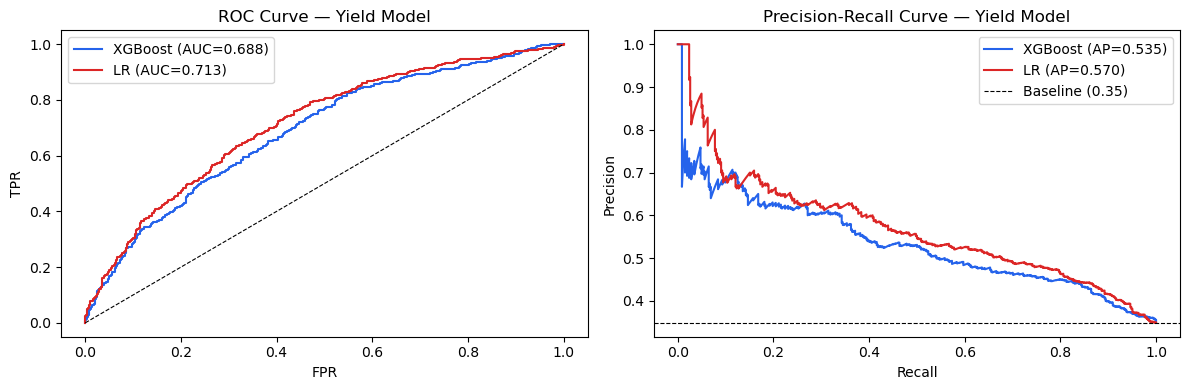

In [5]:
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score

X_test = artifact['X_test']
y_test = artifact['y_test']

xgb_prob = artifact['xgb'].predict_proba(X_test)[:, 1]
lr_prob  = artifact['lr'].predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for prob, label, color in [(xgb_prob, 'XGBoost', '#2563eb'), (lr_prob, 'LR', '#dc2626')]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    prec, rec, _ = precision_recall_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ap  = average_precision_score(y_test, prob)
    axes[0].plot(fpr, tpr, label=f'{label} (AUC={auc:.3f})', color=color)
    axes[1].plot(rec, prec, label=f'{label} (AP={ap:.3f})', color=color)

axes[0].plot([0,1],[0,1],'k--', lw=0.8)
axes[0].set(title='ROC Curve — Yield Model', xlabel='FPR', ylabel='TPR')
axes[0].legend()

baseline = y_test.mean()
axes[1].axhline(baseline, color='k', linestyle='--', lw=0.8, label=f'Baseline ({baseline:.2f})')
axes[1].set(title='Precision-Recall Curve — Yield Model', xlabel='Recall', ylabel='Precision')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'yield_roc_pr.png', bbox_inches='tight')
plt.show()

## Calibration plot

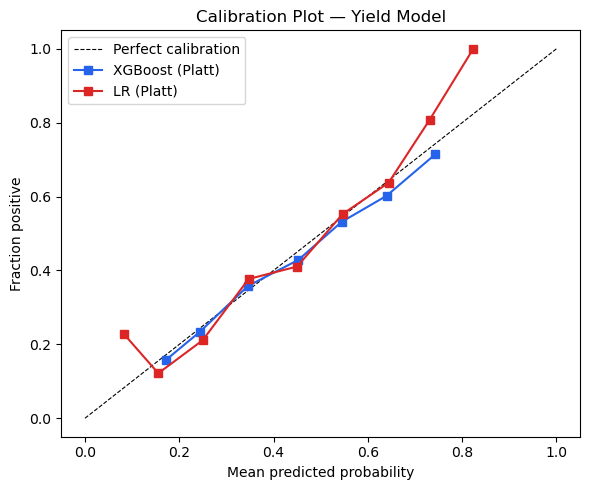

In [6]:
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], 'k--', lw=0.8, label='Perfect calibration')

for prob, label, color in [(xgb_prob, 'XGBoost (Platt)', '#2563eb'), (lr_prob, 'LR (Platt)', '#dc2626')]:
    frac_pos, mean_pred = calibration_curve(y_test, prob, n_bins=10)
    ax.plot(mean_pred, frac_pos, 's-', label=label, color=color)

ax.set(title='Calibration Plot — Yield Model', xlabel='Mean predicted probability', ylabel='Fraction positive')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'yield_calibration.png', bbox_inches='tight')
plt.show()

## Score all admitted applicants and save

In [7]:
predictions = ym.predict(artifact, admits)
predictions_full = admits[['applicant_id', 'institution_segment', 'race_ethnicity',
                            'gender', 'first_gen_flag', 'income_band',
                            'admit_to_enroll']].merge(predictions, on='applicant_id')

out_path = OUTPUT_DIR / 'yield_predictions.csv'
predictions_full.to_csv(out_path, index=False)
print(f'Saved {len(predictions_full):,} admitted applicants to {out_path}')
predictions_full[['yield_probability', 'yield_score_raw']].describe().round(3)

Saved 8,860 admitted applicants to C:\Users\jeged\Downloads\Enrollment Decline & Demographic Shift AI System\data\output\yield_predictions.csv


,yield_probability,yield_score_raw
count,8860.000,8860.000
mean,35.284,0.353
std,15.710,0.157
min,11.800,0.118
25%,22.200,0.222
50%,31.400,0.314
75%,46.300,0.463
max,79.700,0.797


## Predicted yield by institution segment

In [8]:
from src.data_synthesis import YIELD_TARGET_BY_SEGMENT

seg_pred = predictions_full.groupby('institution_segment').agg(
    predicted_yield=('yield_score_raw', 'mean'),
    predicted_count=('yield_score_raw', lambda x: (x >= 0.5).sum()),
    admitted_count=('admit_to_enroll', 'count'),
    actual_yield=('admit_to_enroll', 'mean'),
).assign(target_yield=lambda d: d.index.map(YIELD_TARGET_BY_SEGMENT))

seg_pred[['predicted_yield', 'actual_yield', 'target_yield', 'predicted_count', 'admitted_count']].round(3)

,predicted_yield,actual_yield,target_yield,predicted_count,admitted_count
institution_segment,,,,,
R1,0.327,0.323,0.33,113,1059
community_college,0.497,0.517,0.50,1237,2473
online,0.380,0.413,0.40,217,1151
private_lac,0.298,0.273,0.28,168,1357
regional_state,0.251,0.221,0.22,47,2820


## Save model artifact

In [9]:
saved = ym.save(artifact)
print(f'Artifact saved to {saved}')

Artifact saved to C:\Users\jeged\Downloads\Enrollment Decline & Demographic Shift AI System\models\yield_prediction.pkl
